<a href="https://colab.research.google.com/github/RiderTheSpeedLover/Jio_Institute/blob/Dimesionality-reduction/PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


===== Explained Variance Ratio =====
 [0.4595174  0.17181626 0.13004259 0.11053162 0.07340211 0.02484235
 0.0126043  0.00981282 0.00743056]

===== PCA Component Loadings =====
      child_mort   exports    health   imports    income  inflation  \
PC1   -0.419519  0.283897  0.150838  0.161482  0.398441  -0.193173   
PC2    0.192884  0.613163 -0.243087  0.671821  0.022536  -0.008404   
PC3   -0.029544  0.144761 -0.596632 -0.299927  0.301548   0.642520   
PC4    0.370653  0.003091  0.461897 -0.071907  0.392159   0.150442   
PC5   -0.168970  0.057616  0.518000  0.255376 -0.247150   0.714869   
PC6   -0.200628  0.059333 -0.007276  0.030032 -0.160347  -0.066285   
PC7    0.079489  0.707303  0.249831 -0.592190 -0.095562  -0.104633   
PC8    0.682743  0.014197 -0.072497  0.028946 -0.352624   0.011538   
PC9   -0.327542  0.123082 -0.113088 -0.099037 -0.612982   0.025236   

     life_expec  total_fer      gdpp  
PC1    0.425839  -0.403729  0.392645  
PC2   -0.222707   0.155233 -0.046022  
PC3 

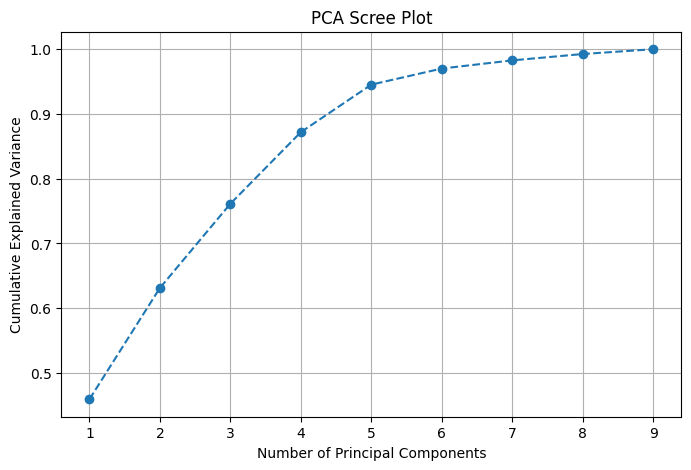

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv("pca.csv")

# Drop non-numeric column (country)
df_numeric = df.drop(columns=["country"])

# Standardize the data (important for PCA)
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_numeric)

# Apply PCA
pca = PCA(n_components=len(df_numeric.columns))  # Keep all components initially
principal_components = pca.fit_transform(df_scaled)

# Create a DataFrame for PCA results
df_pca = pd.DataFrame(data=principal_components, columns=[f"PC{i+1}" for i in range(len(df_numeric.columns))])

# Explained Variance Ratio
explained_variance = pca.explained_variance_ratio_

# Get PCA Component Loadings (weights of original variables in each PC)
loadings = pd.DataFrame(
    pca.components_,
    columns=df_numeric.columns,
    index=[f"PC{i+1}" for i in range(len(df_numeric.columns))]
)

# Print Explained Variance
print("\n===== Explained Variance Ratio =====\n", explained_variance)

# Print Loadings (Feature Contributions to Each PC)
print("\n===== PCA Component Loadings =====\n", loadings)

# Scree Plot (Explained Variance)
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance) + 1), np.cumsum(explained_variance), marker="o", linestyle="--")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Scree Plot")
plt.grid()
plt.show()
